In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm import tqdm
import re
import json

def printShape(df, cols=[], msg=''):
    
    print(df.shape, end='  ')
    for col in cols:
        if col in df.columns:
            print(col, df[col].nunique(), end='  ')
    print(msg, flush=True)
    
    return df

PROJDATA = '../data'
PLOS = f'{PROJDATA}/plos'
LARGE = f'{PROJDATA}/large_files'
EXTERNAL = '/scratch/fl1092/LLM_use_RAD/data'

In [2]:
%%time
languageRating = pd.read_csv(f'{PLOS}/LanguageRating.csv',parse_dates=['date']).pipe(printShape) # 136647
paperRating = pd.read_csv(f'{PLOS}/PaperRating.csv',parse_dates=['date']).pipe(printShape) # 132957
firstRound = pd.read_csv(f'{PLOS}/PeerReviewFirstRounds.csv').pipe(printShape) # 44631
lastRound = pd.read_csv(f'{PLOS}/PeerReviewLastRounds.csv').pipe(printShape) # 36201

(136647, 6)  
(132957, 6)  
(44631, 2)  
(36201, 2)  
CPU times: user 317 ms, sys: 40.9 ms, total: 358 ms
Wall time: 365 ms


In [3]:
paperYear = pd.read_csv(f'{PLOS}/papers_meta.csv', usecols=['paper_id', 'year'])

paperID = (
    pd.read_csv(f'{PLOS}/PaperID.csv')
    .assign(PLOSPaperID=lambda df: df.paper_id.apply(lambda x: '.'.join(x.split('.')[-2:])))
    .assign(Journal=lambda df: df.paper_id.apply(lambda x: x.split('.')[-2]))
    .pipe(printShape, cols=['PLOSPaperID'])
    
    .merge(paperYear, on='paper_id')
    .pipe(printShape, cols=['PLOSPaperID']) # (348687, 4)  PLOSPaperID 348672   
    .drop('paper_id', axis=1)
)

del paperYear

(348687, 4)  PLOSPaperID 348672  
(348687, 5)  PLOSPaperID 348672  


In [4]:
%%time
classifications = (
    pd.read_csv(
        f'{EXTERNAL}/ClassificationsAggregated.csv',
        usecols=['PaperID', 'DetectAbs7','DetectAbs','DetectIntro7','BinoAbs']
    )
    .pipe(printShape, cols=['PaperID']) # (6865733, 2)  PaperID 6861026 
)

(6865733, 5)  PaperID 6861026  
CPU times: user 10.5 s, sys: 583 ms, total: 11.1 s
Wall time: 11.1 s


In [5]:
%%time
papMainCountry = pd.read_csv(f'{PLOS}/PaperMainCountry.csv').pipe(printShape, cols=['PLOSPaperID']) # (363813, 9)  PLOSPaperID 363813

mostFrequentCountries = (
    papMainCountry.Country.value_counts().reset_index().drop('count', axis=1).head(20)
    .assign(TopCountry=lambda df: df.Country)
)

papMainTopCountry = (
    papMainCountry.merge(mostFrequentCountries, on='Country', how='left')
    .fillna({'TopCountry':'Others'})
    .drop('Country', axis=1)
    .rename(columns={'TopCountry':'Country'})
    .pipe(printShape, cols=['PLOSPaperID'])
)

(363813, 8)  PLOSPaperID 363813  
(363813, 8)  PLOSPaperID 363813  
CPU times: user 753 ms, sys: 37.9 ms, total: 791 ms
Wall time: 796 ms


In [6]:
%%time
editorDuration = pd.read_csv(f'{PLOS}/PeerReviewEditorDuration.csv', parse_dates=['prev_date','curr_date'])
authorDuration = pd.read_csv(f'{PLOS}/PeerReviewAuthorDuration.csv', parse_dates=['decision_date','response_date'])

CPU times: user 210 ms, sys: 3.69 ms, total: 214 ms
Wall time: 214 ms


In [7]:
reviewLLM = pd.read_csv(f'{PLOS}/ReviewerUsingLLM.csv', parse_dates=['curr_date'])

# Regression analysis

In [8]:
from statsmodels.formula.api import ols, logit
from scipy.stats import ttest_ind
from statsmodels.iolib.summary2 import summary_col

In [9]:
import pandas as pd
import numpy as np
import scipy
from scipy.stats import ttest_1samp, ttest_ind
import glob

from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib

cm = 1/2.54  # centimeters in inches
font = {'size': 7}
matplotlib.rc('font', **font)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.use14corefonts'] = True

matplotlib.rcParams['grid.linewidth'] = 0.5
matplotlib.rcParams['axes.linewidth'] = 0.5

def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)
    
import numpy as np
from scipy.interpolate import make_smoothing_spline
import scipy

## Analysis of reviewer rating

In [10]:
def getRating2plot(ratingDf):
    
    yesCount = (
        ratingDf.query('Rating == "yes"')
        .groupby(['PLOSPaperID', 'sub_article_id']).Reviewer.nunique().reset_index()
        .rename(columns={'Reviewer':'YesCount'})
        .pipe(printShape, msg='yes count')
    )

    noCount = (
        ratingDf.query('Rating == "no"')
        .groupby(['PLOSPaperID', 'sub_article_id']).Reviewer.nunique().reset_index()
        .rename(columns={'Reviewer':'NoCount'})
        .pipe(printShape, msg='no count')
    )

    reviwerCount = (
        ratingDf.groupby(['PLOSPaperID', 'sub_article_id','date'])
        .Reviewer.nunique().reset_index()
        .rename(columns={'Reviewer':'ReviewerCount'})
        .pipe(printShape, msg='reviewer count')
    )
    
    with pd.option_context("future.no_silent_downcasting", True):
        
        rating =  (
            reviwerCount.pipe(printShape, cols=['sub_article_id'])
            .assign(year=lambda df: df.date.dt.year)
            .assign(Month=lambda df: df.date.dt.month)

            .merge(yesCount, on=['sub_article_id','PLOSPaperID'], how='left')
            .merge(noCount, on=['sub_article_id','PLOSPaperID'], how='left')
            .pipe(printShape, cols=['PLOSPaperID'], msg='merged reviewer, yes, no count')
            .fillna({'YesCount': 0, 'NoCount': 0})

            .merge(firstRound, on=['sub_article_id'], how='left')
            .merge(lastRound, on=['sub_article_id'], how='left')

            .fillna({'FirstRound': False, 'LastRound': False})
            .pipe(printShape, cols=['sub_article_id','PLOSPaperID'])

            .merge(paperID.drop('year', axis=1), on='PLOSPaperID')
            .pipe(printShape, cols=['PLOSPaperID','PaperID'])

            .merge(classifications, on='PaperID')
            .pipe(printShape, cols=['PLOSPaperID','PaperID'], msg='get classification')

            .assign(AllYes=lambda df: df.YesCount == df.ReviewerCount)
            .assign(AllNo=lambda df: df.NoCount == df.ReviewerCount)
            .assign(Mix=lambda df: (~df.AllYes) & (~df.AllNo))
        )
        
        # make sure that papers have both first and last round
        
        firstRoundPapers = (
            rating.query('FirstRound==True')[['PLOSPaperID']]
            .pipe(printShape, cols=['PLOSPaperID'], msg='first round unique papers')
        )
        lastRoundPapers = (
            rating.query('LastRound==True')[['PLOSPaperID']]
            .pipe(printShape, cols=['PLOSPaperID'], msg='last round unique papers')
        )
        
        rating = (
            rating.pipe(printShape, cols=['PLOSPaperID'])
            .merge(firstRoundPapers, on='PLOSPaperID').merge(lastRoundPapers, on='PLOSPaperID')
            .pipe(printShape, cols=['PLOSPaperID'])
            
            .query('FirstRound==True or LastRound==True')
            .pipe(printShape, cols=['PLOSPaperID'], msg='either first round or last rond')

            .merge(papMainTopCountry, on='PLOSPaperID', how='left')
            .pipe(printShape, cols=['PLOSPaperID'], msg='get paper country')

            .assign(AfterGPT=lambda df: df.year > 2022)
            .assign(EventBin=lambda df: df.year-2022)
        )

        rating = (
            rating[rating.Journal.isin(['pone','pgph','pdig'])]
            .pipe(printShape, cols=['PLOSPaperID'], msg='remove journals with handful of papers')
        )
        
        return rating

In [11]:
languageRating2Plot = getRating2plot(languageRating)
# (66035, 3)  yes count
# (12308, 3)  no count
# (69681, 4)  reviewer count
# ...
# (54635, 30)  PLOSPaperID 31776  get paper country
# (54623, 32)  PLOSPaperID 31770  remove journals with handful of papers

(66035, 3)  yes count
(12308, 3)  no count
(69681, 4)  reviewer count
(69681, 4)  sub_article_id 69681  
(69681, 8)  PLOSPaperID 36197  merged reviewer, yes, no count
(69681, 10)  sub_article_id 69681  PLOSPaperID 36197  
(61863, 12)  PLOSPaperID 32337  PaperID 32337  
(61512, 16)  PLOSPaperID 32136  PaperID 32136  get classification
(31780, 1)  PLOSPaperID 31779  first round unique papers
(32134, 1)  PLOSPaperID 32133  last round unique papers
(61512, 19)  PLOSPaperID 32136  
(60951, 19)  PLOSPaperID 31776  
(54635, 19)  PLOSPaperID 31776  either first round or last rond
(54635, 26)  PLOSPaperID 31776  get paper country
(54623, 28)  PLOSPaperID 31770  remove journals with handful of papers


In [12]:
paperRating2Plot = getRating2plot(paperRating)
# (59784, 3)  yes count
# (5549, 3)  no count
# (67804, 4)  reviewer count
# ...
# (53279, 30)  PLOSPaperID 30964  get paper country
# (53267, 32)  PLOSPaperID 30958  remove journals with handful of papers

(59784, 3)  yes count
(5549, 3)  no count
(67804, 4)  reviewer count
(67804, 4)  sub_article_id 67804  
(67804, 8)  PLOSPaperID 35197  merged reviewer, yes, no count
(67804, 10)  sub_article_id 67804  PLOSPaperID 35197  
(60368, 12)  PLOSPaperID 31526  PaperID 31526  
(60019, 16)  PLOSPaperID 31325  PaperID 31325  get classification
(30970, 1)  PLOSPaperID 30969  first round unique papers
(31321, 1)  PLOSPaperID 31320  last round unique papers
(60019, 19)  PLOSPaperID 31325  
(59462, 19)  PLOSPaperID 30964  
(53279, 19)  PLOSPaperID 30964  either first round or last rond
(53279, 26)  PLOSPaperID 30964  get paper country
(53267, 28)  PLOSPaperID 30958  remove journals with handful of papers


### Regression analysis

In [13]:
def quality_regression_models(
    df: pd.DataFrame, classify_col: str, timeEvent='AfterGPT',
    regionControl='GlobalSouth'
):
    
    assert(timeEvent in ['AfterGPT', 'C(EventBin, Treatment(reference=0))'])

    df = df.assign(AllYes=lambda df: df.AllYes.astype(int))
    
    formulas = [
        f"AllYes ~ {classify_col}",
        f"AllYes ~ {classify_col} + {timeEvent} + {timeEvent} * {classify_col}",
        (
            f"AllYes ~ {classify_col} + {timeEvent} + {timeEvent} * {classify_col} + "
            "Total + C(Journal) + C(Country) + C(Month) + year"
        ),
        # (
        #     f"AllYes ~ {classify_col} + {timeEvent} + {timeEvent} * {classify_col} + "
        #     "Total + C(Journal) + C(Country) + C(Month) + year +"
        #     f"{regionControl}+{regionControl}*{timeEvent}+{regionControl}*{classify_col} + "
        #     f"{regionControl}*{timeEvent}*{classify_col}"
        # ),
    ]

    fits = [logit(formula, data=df).fit() for formula in formulas]
    return formulas, fits


def summarize_duration_regression(classify_col: str, fits: list) -> str:
    
    names = ['I','II','III','IV','V','VI']
    order = [
        f"{classify_col}[T.True]",
        "AfterGPT[T.True]",
        f"AfterGPT[T.True]:{classify_col}[T.True]",
        f"NonEnglish[T.True]:AfterGPT[T.True]:{classify_col}[T.True]",
        f"IsEnglish[T.True]:AfterGPT[T.True]:{classify_col}[T.True]"
    ]

    summary = summary_col(
        fits, regressor_order=order, stars=True, drop_omitted=True, model_names=names[:len(fits)]
    )
    return summary.as_text()

In [14]:
def extractInteractionTermAndDraw(models, ax, coeffToDraw, coeffLabels, coeffsToColor=[]):

    def plotOne(x, model, name, color='grey'):

        coef = model.params[name]
        stderr = model.bse[name]
    
        # ax.errorbar(
        #     x=x, y=coef, yerr=stderr*1.96, fmt='o', label='Percent_within',
        #     color=color, capsize=2.5, markersize=1.5, elinewidth=1
        # )

        ax.errorbar(
            y=x, x=coef, xerr=stderr*1.96, fmt='o', label='Percent_within',
            color=color, capsize=2.5, markersize=1.5, elinewidth=1
        )

    for ind, model in enumerate(models):

        # if name in coeffsToColor:
        plotOne(ind, model, coeffToDraw)
        # else:
            # plotOne(ind, name)

    N = len(models)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks([x for x in range(N)])
    ax.set_yticklabels(coeffLabels)

    ax.plot([0,0], [-0.5, N+0.5], lw=0.5, ls='--', color='grey')

    #plt.xticks(rotation=90)
    ax.set_ylim(-0.5, N-.5)

In [15]:
%%time
classify_col = 'DetectAbs'

modelsToPlot = []

formulas, fits = quality_regression_models(
    languageRating2Plot.query('FirstRound==True'), classify_col=classify_col,
)
modelsToPlot.append(fits[-1])

formulas, fits = quality_regression_models(
    languageRating2Plot.query('FirstRound==False'), classify_col=classify_col,
)
modelsToPlot.append(fits[-1])

formulas, fits = quality_regression_models(
    paperRating2Plot.query('LastRound==True'), classify_col=classify_col,
)
modelsToPlot.append(fits[-1])

formulas, fits = quality_regression_models(
    paperRating2Plot.query('LastRound==False'), classify_col=classify_col,
)
modelsToPlot.append(fits[-1])

Optimization terminated successfully.
         Current function value: 0.564482
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.564203
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.523084
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.481145
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.480605
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.476747
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.605525
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.604980
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.602770
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.663654
  

CPU times: user 323 ms, sys: 308 ms, total: 631 ms
Wall time: 8.72 s


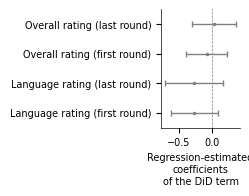

In [16]:
%%time
ax = plt.gca()
labels = [
    'Language rating (first round)', 'Language rating (last round)',
    'Overall rating (first round)', 'Overall rating (last round)'
]
ylabel = 'Regression-estimated\ncoefficients\nof the DiD term'

extractInteractionTermAndDraw(modelsToPlot, ax, f'AfterGPT[T.True]:{classify_col}[T.True]', labels)

set_size(2*cm, 3*cm, ax)
ax.set_xlabel(ylabel)

plt.savefig('../figures/Language_paper_quality_DiD.pdf',bbox_inches = 'tight', pad_inches = 0)

## Analysis of peer review turnaround

In [17]:
timeToRegress = (
    pd.concat([
        (
            editorDuration.rename(columns={'editor_stage':'round'})
            .assign(Year=lambda df: df.curr_date.apply(lambda x: x.year))
            .assign(Month=lambda df: df.curr_date.apply(lambda x: x.month))
            
            .drop(['prev_event','curr_event','prev_date'], axis=1)
            
            .assign(IsAuthor=False)
        ),
        (
            authorDuration
            .assign(Year=lambda df: df.response_date.apply(lambda x: x.year))
            .assign(Month=lambda df: df.response_date.apply(lambda x: x.month))
            
            .drop(['decision_date', 'stage_type'], axis=1)
            .rename(columns={'response_date':'curr_date'})
            
            .assign(IsAuthor=True)
        )
    ], ignore_index=True)
    # .assign(Journal=lambda df: df.PLOSPaperID.apply(lambda x: x.split('.')[0]))
    
    .merge(papMainCountry, on='PLOSPaperID')
    .merge(paperID, on='PLOSPaperID')
    .merge(classifications, on='PaperID')
    
    .assign(AfterGPT=lambda df: df.year>=2023)
    .assign(EventBin=lambda df: df.year-2022)

    .pipe(printShape, cols=['PLOSPaperID','PaperID']) # (154911, 24)  PLOSPaperID 39257  PaperID 39257  
)

(154911, 23)  PLOSPaperID 39257  PaperID 39257  


## Regression analysis

In [18]:
from statsmodels.formula.api import ols, logit
from scipy.stats import ttest_ind
from statsmodels.iolib.summary2 import summary_col

In [19]:
from matplotlib import pyplot as plt

def drawCoefficientPlot(model, ax, coeffsToDraw, coeffsMap, coeffsToColor=[]):

    def plotOne(x, name, color='grey'):

        coef = model.params[name]
        stderr = model.bse[name]

        print(f'{name}: {coef:.3f}, 95%-CI: [{coef-stderr*1.96:.3f}, {coef+stderr*1.96:.3f}]')
    
        ax.errorbar(
            x=x, y=coef, yerr=stderr*1.96, fmt='o', label='Percent_within',
            color=color, capsize=2.5, markersize=1.5, elinewidth=1
        )

    for ind, name in enumerate(coeffsToDraw):

        if name in coeffsToColor:
            plotOne(ind, name, 'tab:blue')
        else:
            plotOne(ind, name)

    N = len(coeffsToDraw)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([x for x in range(N)])
    ax.set_xticklabels([coeffsMap[x] for x in coeffsToDraw])

    ax.plot([-0.5, N-0.5], [0,0], lw=0.5, ls='--', color='grey')

    plt.xticks(rotation=90)
    ax.set_xlim(-0.5, N+.5)

In [20]:
def duration_regression_models(df: pd.DataFrame, classify_cols: list, timeEvent='AfterGPT'):
    assert(timeEvent in ['AfterGPT', 'C(EventBin, Treatment(reference=0))'])
    
    formulas = [
        f"duration_days ~ {'+'.join(classify_cols)}",
        (
            f"duration_days ~ {' + '.join(classify_cols)} + {timeEvent} + "
            f"{' + '.join([f'{timeEvent}*'+x for x in classify_cols])}"
        ),
        (
            f"duration_days ~ {' + '.join(classify_cols)} + {timeEvent} + "
            f"{' + '.join([f'{timeEvent}*'+x for x in classify_cols])} + "
            "Total + C(Journal) + C(Country) + C(Month) + year + round" #
        ),
    ]

    fits = [ols(formula, data=df).fit() for formula in formulas]
    return formulas, fits


def summarize_duration_regression(classify_col: str, fits: list) -> str:
    
    names = ['I','II','III','IV','V','VI']
    order = [
        f"{classify_col}[T.True]",
        "AfterGPT[T.True]",
        "ReviewerLLM[T.True]",
        f"AfterGPT[T.True]:{classify_col}[T.True]",
        f"AfterGPT[T.True]:ReviewerLLM[T.True]",
    ]

    summary = summary_col(
        fits, regressor_order=order, stars=True, drop_omitted=True, model_names=names[:len(fits)]
    )
    return summary.as_text()

### Editor-side

In [21]:
classify_col = 'DetectAbs'

duration_df = (
    timeToRegress.query('IsAuthor==False')
    .dropna(subset=[classify_col, "duration_days", "Year", "Month"])
    .pipe(printShape) # 97075
)

formulas, fits = duration_regression_models(
    duration_df, [classify_col],
    timeEvent='C(EventBin, Treatment(reference=0))'
)

(97075, 23)  


C(EventBin, Treatment(reference=0))[T.-3]:DetectAbs[T.True]: 5.866, 95%-CI: [-9.246, 20.978]
C(EventBin, Treatment(reference=0))[T.-2]:DetectAbs[T.True]: 3.325, 95%-CI: [-2.937, 9.588]
C(EventBin, Treatment(reference=0))[T.-1]:DetectAbs[T.True]: 4.068, 95%-CI: [-2.036, 10.172]
C(EventBin, Treatment(reference=0))[T.1]:DetectAbs[T.True]: 0.690, 95%-CI: [-4.843, 6.224]
C(EventBin, Treatment(reference=0))[T.2]:DetectAbs[T.True]: -1.555, 95%-CI: [-6.285, 3.175]


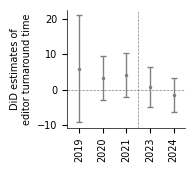

In [22]:
ax = plt.gca()
set_size(4*cm, 5*cm, ax)

drawCoefficientPlot(
    fits[-1], ax,
    coeffsToDraw=[
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]',
        
    ],
    coeffsMap={
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]':'2019',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]':'2020',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]':'2021',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]':'2023',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]':'2024',
    },
)

ylim = ax.get_ylim()
ax.plot([2.5, 2.5], ylim, ls='--', lw=0.5, color='grey')
ax.set_ylim(ylim)
ax.set_xlim(-0.5, 4.5)
ax.set_ylabel('DiD estimates of\neditor turnaround time')
set_size(3*cm, 3*cm, ax)

plt.savefig('../figures/editor_duration_regression_DiD.pdf',bbox_inches = 'tight', pad_inches = 0)

### Author-side

In [23]:
classify_col = 'DetectAbs'

duration_df = (
    timeToRegress.query('IsAuthor==True')
    .dropna(subset=[classify_col, "duration_days", "Year", "Month"])
    .pipe(printShape) # 57823
)

formulas, fits = duration_regression_models(
    duration_df, [classify_col],
    timeEvent='C(EventBin, Treatment(reference=0))'
)

(57823, 23)  


C(EventBin, Treatment(reference=0))[T.-3]:DetectAbs[T.True]: 12.780, 95%-CI: [-6.073, 31.632]
C(EventBin, Treatment(reference=0))[T.-2]:DetectAbs[T.True]: -0.634, 95%-CI: [-8.073, 6.806]
C(EventBin, Treatment(reference=0))[T.-1]:DetectAbs[T.True]: -1.375, 95%-CI: [-8.666, 5.916]
C(EventBin, Treatment(reference=0))[T.1]:DetectAbs[T.True]: -8.902, 95%-CI: [-15.492, -2.312]
C(EventBin, Treatment(reference=0))[T.2]:DetectAbs[T.True]: -8.334, 95%-CI: [-13.999, -2.670]


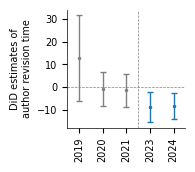

In [24]:
ax = plt.gca()
set_size(4*cm, 4*cm, ax)

drawCoefficientPlot(
    fits[-1], ax,
    coeffsToDraw=[
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]',
        
    ],
    coeffsMap={
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]':'2019',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]':'2020',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]':'2021',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]':'2023',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]':'2024',
    },
    coeffsToColor=[
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]'
    ]
)

ylim = ax.get_ylim()
ax.plot([2.5, 2.5], ylim, ls='--', lw=0.5, color='grey')
ax.set_ylim(ylim)
ax.set_xlim(-0.5, 4.5)
ax.set_ylabel('DiD estimates of\nauthor revision time')

set_size(3*cm, 3*cm, ax)

plt.savefig('../figures/author_duration_regression_DiD.pdf',bbox_inches = 'tight', pad_inches = 0)

#### Regional heterogeneity

In [25]:
classify_col = 'DetectAbs'

duration_df = (
    timeToRegress.query('IsAuthor==True')
    .query('GlobalSouth == True').pipe(printShape) # 21972
    .dropna(subset=[classify_col, "duration_days", "Year", "Month"]).pipe(printShape) # 21971
)

formulas, fits = duration_regression_models(
    duration_df, [classify_col],
    timeEvent='C(EventBin, Treatment(reference=0))'
)

(21972, 23)  
(21971, 23)  


C(EventBin, Treatment(reference=0))[T.-3]:DetectAbs[T.True]: 5.997, 95%-CI: [-22.322, 34.316]
C(EventBin, Treatment(reference=0))[T.-2]:DetectAbs[T.True]: -3.674, 95%-CI: [-17.119, 9.771]
C(EventBin, Treatment(reference=0))[T.-1]:DetectAbs[T.True]: -8.389, 95%-CI: [-22.264, 5.486]
C(EventBin, Treatment(reference=0))[T.1]:DetectAbs[T.True]: -13.385, 95%-CI: [-24.590, -2.180]
C(EventBin, Treatment(reference=0))[T.2]:DetectAbs[T.True]: -12.657, 95%-CI: [-22.463, -2.851]


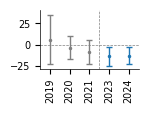

In [26]:
ax = plt.gca()

drawCoefficientPlot(
    fits[-1], ax,
    coeffsToDraw=[
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]',
        
    ],
    coeffsMap={
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]':'2019',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]':'2020',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]':'2021',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]':'2023',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]':'2024',
    },
    coeffsToColor=[
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]'
    ]
)

ax.plot([2.5, 2.5], [-28, 41], ls='--', lw=0.5, color='grey')
ax.set_ylim([-28, 41])
ax.set_xlim(-0.5, 4.5)
#ax.set_ylabel('DiD estimates of\nauthor revision time')

set_size(2.5*cm, 1.5*cm, ax)

plt.savefig('../figures/author_duration_regression_DiD_global_south.pdf',bbox_inches = 'tight', pad_inches = 0)

In [27]:
classify_col = 'DetectAbs'

duration_df = (
    timeToRegress.query('IsAuthor==True').pipe(printShape)
    .query('GlobalSouth == False').pipe(printShape) # 35856
    .dropna(subset=[classify_col, "duration_days", "Year", "Month"]).pipe(printShape) # 35852
)

formulas, fits = duration_regression_models(
    duration_df, [classify_col],
    timeEvent='C(EventBin, Treatment(reference=0))'
)

(57828, 23)  
(35856, 23)  
(35852, 23)  


C(EventBin, Treatment(reference=0))[T.-3]:DetectAbs[T.True]: 13.544, 95%-CI: [-11.608, 38.696]
C(EventBin, Treatment(reference=0))[T.-2]:DetectAbs[T.True]: 0.633, 95%-CI: [-8.370, 9.635]
C(EventBin, Treatment(reference=0))[T.-1]:DetectAbs[T.True]: 0.916, 95%-CI: [-7.775, 9.607]
C(EventBin, Treatment(reference=0))[T.1]:DetectAbs[T.True]: -6.826, 95%-CI: [-15.095, 1.443]
C(EventBin, Treatment(reference=0))[T.2]:DetectAbs[T.True]: -5.228, 95%-CI: [-12.489, 2.034]


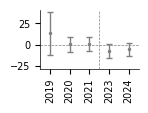

In [28]:
ax = plt.gca()

drawCoefficientPlot(
    fits[-1], ax,
    coeffsToDraw=[
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]',
        
    ],
    coeffsMap={
        f'C(EventBin, Treatment(reference=0))[T.-3]:{classify_col}[T.True]':'2019',
        f'C(EventBin, Treatment(reference=0))[T.-2]:{classify_col}[T.True]':'2020',
        f'C(EventBin, Treatment(reference=0))[T.-1]:{classify_col}[T.True]':'2021',
        f'C(EventBin, Treatment(reference=0))[T.1]:{classify_col}[T.True]':'2023',
        f'C(EventBin, Treatment(reference=0))[T.2]:{classify_col}[T.True]':'2024',
    },
)

ax.plot([2.5, 2.5], [-28, 41], ls='--', lw=0.5, color='grey')
ax.set_ylim([-28, 41])
ax.set_xlim(-0.5, 4.5)
#ax.set_ylabel('DiD estimates of\nauthor revision time')

set_size(2.5*cm, 1.5*cm, ax)

plt.savefig('../figures/author_duration_regression_DiD_global_north.pdf',bbox_inches = 'tight', pad_inches = 0)